In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from scipy.stats import uniform
from scipy import stats

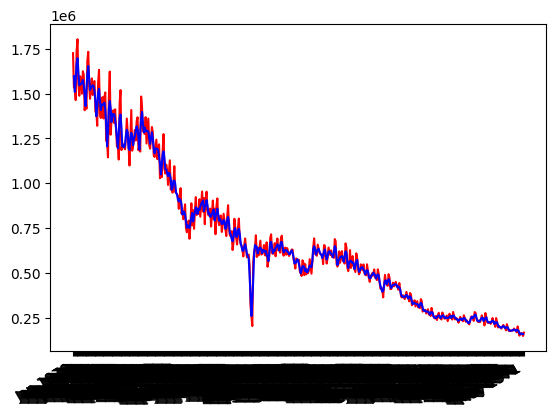

In [11]:
tourist = pd.read_csv("../data/tourism_sg.csv")
tourist["Arrivals"] = np.nan_to_num(tourist["Arrivals"], nan = -1)
for i in range(len(tourist["Arrivals"])):
    if tourist["Arrivals"][i] == -1:
        tourist.loc[i,"Arrivals"] = (tourist["Arrivals"][i-1] + tourist["Arrivals"][i+1]) / 2

for i in range(1, len(tourist["Arrivals"]) - 1):
    tourist.loc[i,"mov_avg"] = (tourist["Arrivals"][i-1] + tourist["Arrivals"][i+1] + tourist["Arrivals"][i]) / 3

fig, ax = plt.subplots()
ax.plot(tourist.Month, tourist.Arrivals, color = "red")
ax.plot(tourist.Month, tourist.mov_avg, color = "blue")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate()
plt.show()

In [12]:
def one_sample_n():
    N = 0
    res = 0
    while res < 1:
        res += uniform.rvs(0, 1)
        N += 1
    return N

width = 0
list_of_n = []
upper = 0
lower = 0
while len(list_of_n) < 30 or width > 0.05:
    list_of_n.append(one_sample_n())
    if(len(list_of_n) < 30):
        continue
    std_error = 1.96 * np.std(np.array(list_of_n)) / np.sqrt(len(list_of_n))
    N_bar =  np.mean(np.array(list_of_n))
    upper = N_bar + std_error
    lower = N_bar - std_error
    width = upper - lower

print(len(list_of_n))
print(width)
print(f"Conf int:({lower}, {upper})")

4621
0.049995746045617295
Conf int:(2.6754998547417443, 2.7254956007873616)


0.43544303797468364
0.8531645569620255
Medu0: 1.0
Medu1: 0.8135593220338982
Medu2: 0.8155339805825241
Medu3: 0.8383838383838385
Medu4: 0.9083969465648856


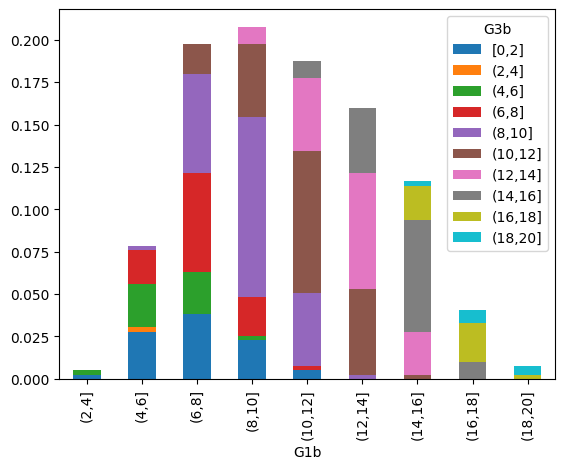

In [108]:
stud = pd.read_csv("../data/student-mat.csv",sep=";")

bins = [0,2,4,6,8,10,12,14,16,18,20]
labels = ["[0,2]", "(2,4]", "(4,6]", "(6,8]", "(8,10]", "(10,12]", "(12,14]", "(14,16]", "(16,18]", "(18,20]"]

stud["G1b"] = pd.cut(stud["G1"], bins= bins, labels=labels, include_lowest=True, right=True)
stud["G3b"] =  pd.cut(stud["G3"], bins= bins, labels=labels, include_lowest=True, right=True)

g1_g3_array = pd.crosstab(stud["G1b"], stud["G3b"], normalize=True)

g1_g3_array.plot(kind="bar", stacked=True)

res = 0
for i in g1_g3_array.keys():
    if i in g1_g3_array[i]:
        res += g1_g3_array[i][i]

print(res)
res = 0
for i in g1_g3_array.keys():
    index = labels.index(i)
    if i in g1_g3_array[i]:
        res += g1_g3_array[i][i]
    if index+1 < len(labels) and labels[index+1] in g1_g3_array[i]:
        res += g1_g3_array[i][labels[index+1]]
    if labels[index-1] in g1_g3_array[i]:
        res += g1_g3_array[i][labels[index-1]]

print(res)
res = 0

for x,y in stud.groupby("Medu"):
    g1_g3_array = pd.crosstab(y["G1b"], y["G3b"], normalize=True, dropna=False)
    res = 0
    for i in g1_g3_array.keys():
        # print(g1_g3_array[i])
        index = labels.index(i)
        if i in g1_g3_array[i]:
            res += g1_g3_array[i][i]
        if index+1 < len(labels):
            res += g1_g3_array[i][labels[index+1]]
        if index - 1 >= 0:
            res += g1_g3_array[i][labels[index-1]]

    print(f"Medu{x}: {res}")

In [107]:
stud_perf = pd.read_csv("../data/student-mat.csv", sep=";")
stud_perf['G1_bin'] = pd.cut(stud_perf.G1, bins=[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20],
                             labels=False, include_lowest=True)
stud_perf['G3_bin'] = pd.cut(stud_perf.G3, bins=[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20],
                             labels=False, include_lowest=True)

#prop_tbl = pd.crosstab(stud_perf.G1_bin, stud_perf.G3_bin, normalize=True)
#prop_tbl.loc[1,0]
#23/395
#pd.crosstab(stud_perf.G1_bin, stud_perf.G3_bin).values.shape
#prop_tbl.style.background_gradient(cmap='coolwarm_r', axis=None, vmin=0, vmax=0.2)
#prop_tbl.loc[1, 2]

def eta(var1, var2, diff=0):
    tbl = pd.crosstab(var1, var2, normalize=True)
    row_vals = tbl.index.values
    col_vals = tbl.columns.values

    eta = 0.0
    for i in row_vals:
        for j in col_vals:
            if np.abs(i - j) <= diff:
                eta += tbl.loc[i, j]
    return eta

eta(stud_perf.G1_bin, stud_perf.G3_bin, diff=0)
for id,df in stud_perf.groupby('Medu'):
    print(eta(df.G1_bin, df.G3_bin, diff=1))

1.0
0.8135593220338981
0.8155339805825241
0.8383838383838383
0.9083969465648857
